# Football Player Evaluation Model - Full Pipeline

This notebook contains the complete pipeline for training and evaluating the football player evaluation model.

## 0. Setup - Imports and Configuration

In [1]:
import pandas as pd

import config
from src.analysis.prediction_utils import matches_info_df
from src.data.data_loader import load_statsbomb_socceraction_data
from src.data.data_splitter import split_matches
from src.ml.models.model_factory import create_model
from src.ml.preprocessing.sequence import SequencePreprocessor
from src.ml.train import ModelTrainer
from src.ml.xthreat import get_default_xt_model

In [2]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
data = load_statsbomb_socceraction_data("data/statsbomb/data", 55, 282)
train_matches, val_matches, test_matches = split_matches(data)

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

## 2. Preprocessing Data

#### Initialize preprocessor with sequence length and xT model

In [4]:
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

#### Process training, validation, and test sets

In [5]:
X_train, y_train, p_train, m_train = preprocessor.process_matches(train_matches)
X_val, y_val, p_val, m_val = preprocessor.process_matches(val_matches)
X_test, y_test, p_test, m_test = preprocessor.process_matches(test_matches)

→Processing match 3930178: 4006 events (mode: training)
 → Generated 1735 sequences, 1735 labels for match 3930178
→Processing match 3930181: 3688 events (mode: training)
 → Generated 1627 sequences, 1627 labels for match 3930181
→Processing match 3930184: 2953 events (mode: training)
 → Generated 1117 sequences, 1117 labels for match 3930184
→Processing match 3930167: 3721 events (mode: training)
 → Generated 1507 sequences, 1507 labels for match 3930167
→Processing match 3938643: 3767 events (mode: training)
 → Generated 1551 sequences, 1551 labels for match 3938643
→Processing match 3942819: 3485 events (mode: training)
 → Generated 1657 sequences, 1657 labels for match 3942819
→Processing match 3930170: 3552 events (mode: training)
 → Generated 1484 sequences, 1484 labels for match 3930170
→Processing match 3930179: 3776 events (mode: training)
 → Generated 1589 sequences, 1589 labels for match 3930179
→Processing match 3938641: 3400 events (mode: training)
 → Generated 1200 sequen

#### Display dataset sizes

In [6]:
print(f"Train set: {X_train.shape[0]} sequences with shape {X_train.shape}")
print(f"Val set: {X_val.shape[0]} sequences with shape {X_val.shape}")
print(f"Test set: {X_test.shape[0]} sequences with shape {X_test.shape}")

Train set: 56100 sequences with shape (56100, 6, 46)
Val set: 12647 sequences with shape (12647, 6, 46)
Test set: 8675 sequences with shape (8675, 6, 46)


## 3. Build Model

In [7]:
MODEL_TYPE = 'attention_lstm'  # Options: 'lstm', 'attention_lstm', 'transformer'
model = create_model(
    MODEL_TYPE,
    input_shape=(config.SEQUENCE_LENGTH, X_train.shape[2])
)

# Display model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 6, 46)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 6, 46)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 6, 46)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 6)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 6, 256)    │    179,200 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 6, 256)    │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 6, 128)    │    197,120 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 128)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ [(None, 128),     │        134 │ dropout_1[0][0],  │
│ (AttentionLayer)    │ (None, 6)]        │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 384,775 (1.47 MB)

 Trainable params: 384,775 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model

#### Initialize trainer and train the model

In [9]:
trainer = ModelTrainer(model, f"models/{MODEL_TYPE}/")
trainer.train(
    X_train, y_train,
    X_val, y_val,
    batch_size=config.BATCH_SIZE,
    epochs=config.EPOCHS
)

Epoch 1/50
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - attention_weights_loss: 0.0309 - loss: 4.3999e-04 - value_loss: 4.3983e-04 - value_mae: 0.0077 - val_attention_weights_loss: 0.0310 - val_loss: 7.2315e-04 - val_value_loss: 7.2451e-04 - val_value_mae: 0.0086 - learning_rate: 0.0010
Epoch 2/50
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - attention_weights_loss: 0.0310 - loss: 4.4158e-04 - value_loss: 4.4143e-04 - value_mae: 0.0075 - val_attention_weights_loss: 0.0308 - val_loss: 7.6305e-04 - val_value_loss: 7.6279e-04 - val_value_mae: 0.0081 - learning_rate: 0.0010
Epoch 3/50
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - attention_weights_loss: 0.0311 - loss: 4.1312e-04 - value_loss: 4.1292e-04 - value_mae: 0.0074 - val_attention_weights_loss: 0.0313 - val_loss: 6.2408e-04 - val_value_loss: 6.2432e-04 - val_value_mae: 0.0073 - learning_rate: 0.0010
Epoch 4/50
1754/1754 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - attention_weights_loss: 0.0313 - loss: 3.8803e-04 - value_loss: 3.8784e-

## 5. Evaluate Model

#### 5.1 Evaluate on validation set

In [10]:
from rich import print

val_metrics = trainer.evaluate(X_val, y_val)
print(val_metrics)

396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


{'loss': 0.0005220546154305339, 'mae': 0.0005212865071371198, 'rmse': 0.022848513809349144}

#### 5.2 Evaluate on test set

In [11]:
from rich import print

test_metrics = trainer.evaluate(X_test, y_test)
print(test_metrics)

272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


{'loss': 0.0003050929226446897, 'mae': 0.00030474213417619467, 'rmse': 0.017466910824787945}

## 6. Summary and Results

In [12]:
history_dict = trainer.history.history
print(history_dict.keys())

dict_keys(['attention_weights_loss', 'loss', 'val_attention_weights_loss', 'val_loss', 'val_value_loss', 
'val_value_mae', 'value_loss', 'value_mae', 'learning_rate'])

#### Save training metrics and plots

Metrics saved to models/attention_lstm/metrics.json


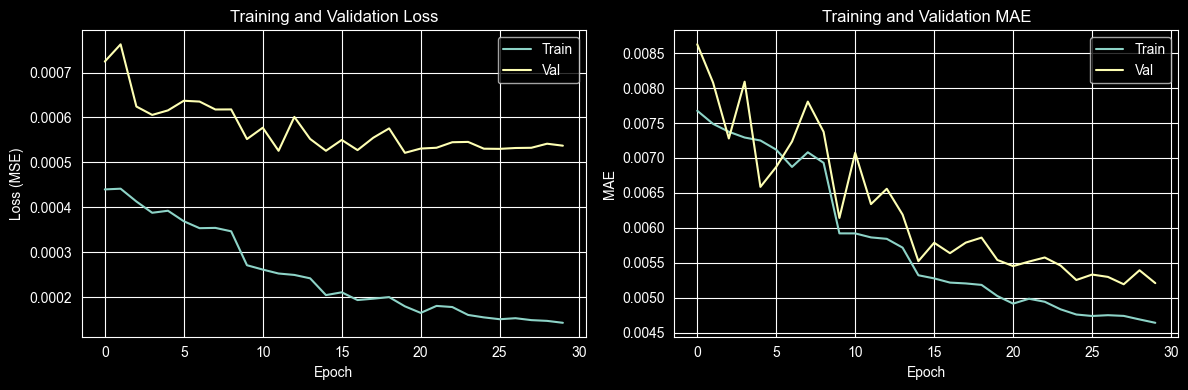

Pipeline completed successfully!

Best model saved as: models/attention_lstm/best_model.keras

In [14]:
all_metrics = {
    'validation': val_metrics,
    'test': test_metrics
}

trainer.save_training_metrics(all_metrics)
trainer.plot_training_history(filename="training_history.png")

print("Pipeline completed successfully!")
print(f"Best model saved as: models/{MODEL_TYPE}/best_model.keras")

## 7. Analysis

#### Extract match information from validation set

In [15]:
val_matches_df = matches_info_df(val_matches)
val_matches_df

,match_id,summary,events_count
0,3930166,Portugal 2 : 1 Czech Republic (Group Stage) [18.06.2024],3602
1,3930165,Austria 0 : 1 France (Group Stage) [17.06.2024],3718
2,3938645,Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024],3525
3,3938637,Poland 1 : 2 Netherlands (Group Stage) [16.06.2024],3401
4,3941017,England 2 : 1 Slovakia (Round of 16) [30.06.2024],4764
5,3938642,Georgia 1 : 1 Czech Republic (Group Stage) [22.06.2024],3332
6,3930177,Scotland 0 : 1 Hungary (Group Stage) [23.06.2024],3386
7,3941021,Romania 0 : 3 Netherlands (Round of 16) [02.07.2024],2996
8,3942382,Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024],3415


#### Summary statistics

In [16]:
print(f"\nValidation Set Summary:")
print(f"Total matches: {len(val_matches_df)}")
print(f"Total events: {val_matches_df['events_count'].sum()}")
print(f"Average events per match: {val_matches_df['events_count'].mean():.2f}")


Validation Set Summary:

Total matches: 9

Total events: 32139

Average events per match: 3571.00